In [2]:
import google.generativeai as genai
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import os
import json
from tqdm import tqdm

In [19]:
prompt = """You are an expert in extracting data from images of complex charts and converting them into a well-formatted CSV table. You will be provided with an image of a single complex chart, which contains multiple data series represented by different legends within the same chart area. Your task is to first carefully analyze the chart, identifying data points, axis labels, chart title, and the legend categories. You will need to carefully match each data point to its corresponding legend to avoid errors. Pay very close attention to all details to avoid any omissions or errors. You will then organize this information into a structured CSV table.

Here's the step-by-step process you should follow:

* Image Analysis: Carefully examine the chart.
    * Identify the Chart's Title/Category: This will often be a heading above or near the chart.
    * Determine the X-Axis Labels: These are the categories or values along the horizontal axis.
    * Identify the Y-Axis Labels: Note the scale and units used on the vertical axis. If units aren't explicit, try to infer them from the context or graph.
    * Identify Legends: Note the various legends or data series present in the chart. These are usually identified by different colors, patterns, or labels.
    * Extract Data Points: Identify each data point within the chart (e.g., points on a line, bar heights) and its corresponding numeric value and the legend to which it belongs. Ensure these values are accurately matched to their location in the graph and the corresponding legend.
    * Units: If units are mentioned in graph title or the axes, note them. Match annotations (if any) to the corresponding ticks on the axes to determine the scale.

* Reasoning: Provide a detailed, step-by-step explanation of your data extraction process. In addition to that, write suitable names for your column headers and write down the value of each data point. Explain how you identified each value and the headers, including any educated guesses you made for missing labels or units. Your reasoning should demonstrate how you understood the relationship between the chart, extracted data, and its corresponding legend.

* Reflection: Reflect on your reasoning process and the accuracy of your extracted data. If you made any assumptions or educated guesses, explain how you arrived at these conclusions. Double-check that all data points are in the correct position for each chart and that your column headers accurately describe the data in the corresponding columns.

* Table Generation: Create the CSV output of the extracted data. The first row should be the column headers, which should be named appropriately based on the information extracted. The remaining rows should contain the data from each legend. Each row should represent a single data point from a single legend.

* Type of Chart: The chart image might contain a single complex chart such as line chart, bar chart, scatter plot etc. Here is what you need to do for each type of chart:
    * Line Chart: Extract the x-axis values, y-axis values and legend name. The first column should be the x-axis label, the second column should be the y-axis label, the third column should be the legend name, and the fourth column should be the units (if provided).
    * Bar Chart: Extract the x-axis values, y-axis values and legend name. The first column should be the x-axis label, the second column should be the y-axis label, the third column should be the legend name, and the fourth column should be the units (if provided).
    * Scatter Plot: Extract the x-axis values, y-axis values and legend name. The first column should be the x-axis label, the second column should be the y-axis label, the third column should be the legend name, and the fourth column should be the units (if provided).
    * Box Plot: Extract the x-axis values, y-axis values, legend name and quartile values. The first column should be the x-axis label, the second column should be the y-axis label, the third column should be the legend name, the fourth should be the 1st quartile value, the fifth column should be the 2nd quartile value, the sixth column should be the 3rd quartile value, and the seventh column should be the units (if provided).
    * Other Chart Types: If the chart type is different from the above, follow the same process of identifying the x-axis values, y-axis values and legend names. Use appropriate CSV formatting guidelines to structure the data.

* Column Header Logic:
    * Make an educated guess about the column headers based on the extracted x-axis values, y-axis values, legend names and chart title.
    * Use the x-axis label as the second column header.
    * Use the y-axis label as the third column header.
    * Use the legend name as the fourth column header.
    * If units are provided, include a fifth column header for units. If not, you can omit this column. For example, if the value on the axes is 60k, but the annotation says 60,000, you can use the full number as the value and omit the units column.

* CSV Formatting:
    * Ensure proper CSV format using commas to separate values.
    * If a value contains a comma, use double quotes around the value.
    * Use newlines to separate rows.
    * Each row should contain all relevant information for a single data point from a single legend.
    * The first row should be the column headers. Name these headers based on the extracted information, if not provided in the chart.

* Accuracy Check: Double check that all data points are in the correct position for each legend. Ensure your column headers accurately describe the data in the corresponding columns.

* In case information is missing: If any of the information is missing from the image, do your best to infer or make a reasonable educated guess. For example, if y-axis label is missing, use the chart title to make a guess or look for a common y-axis name.

Output Format:

Your response must be structured as follows:

<reasoning>
[Detailed step-by-step reasoning, explaining the data extraction process from the complex chart image and identify each value and header.]
</reasoning>
<reflection>
[Reflect on what you reasoned on and correct if necessary]
</reflection>
<table>
[CSV formatted table data]
</table>

Example (using similar sample data, but in the format I now expect, for a single chart):

<reasoning>
I've analyzed the single chart and identified three legends: "New York," "Paris," and "London." Each legend represents spending over a series of years. The X-axis represents the year, Y-axis represents the spend value, and the units is in million USD. I have taken each value from the corresponding position in the graph for each legend. The column headers are 'Year', 'Venue', 'Spend Value', and 'Units'. The values are as follows:
Year,Spend Value,Venue,Units
2020,3.3,New York,Million USD
2020,5.5,Paris,Million USD
2020,4.2,London,Million USD
2021,3.5,New York,Million USD
2021,5.7,Paris,Million USD
2021,4.1,London,Million USD
2022,3.7,New York,Million USD
2022,5.9,Paris,Million USD
2022,4.3,London,Million USD
</reasoning>
<reflection>
I have cross-checked each value with the respective plot and location for accuracy. I have also ensured that the column headers accurately describe the data in the corresponding columns.
</reflection>
<table>
Year,Spend Value,Venue,Units
2020,3.3,New York,Million USD
2020,5.5,Paris,Million USD
2020,4.2,London,Million USD
2021,3.5,New York,Million USD
2021,5.7,Paris,Million USD
2021,4.1,London,Million USD
2022,3.7,New York,Million USD
2022,5.9,Paris,Million USD
2022,4.3,London,Million USD
</table>
"""

In [ ]:
api_keys = [
]

In [21]:
genai.configure(api_key=api_keys[0])

generation_config = {
  "temperature": 1,
  "max_output_tokens": 8192,
}
safety_settings = [
  {
    "category": "HARM_CATEGORY_HARASSMENT",
    "threshold": "BLOCK_NONE"
  },
  {
    "category": "HARM_CATEGORY_HATE_SPEECH",
    "threshold": "BLOCK_NONE"
  },
  {
    "category": "HARM_CATEGORY_SEXUALLY_EXPLICIT",
    "threshold": "BLOCK_NONE"
  },
  {
    "category": "HARM_CATEGORY_DANGEROUS_CONTENT",
    "threshold": "BLOCK_NONE"
  }
]

model = genai.GenerativeModel(
    model_name="gemini-2.0-flash-exp",
    safety_settings=safety_settings, 
    generation_config=generation_config
)

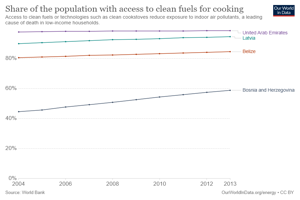

In [22]:
df = pd.read_json('../type1/qa.json')
indices = df['image_index'].unique()
image_names = [str(i) for i in indices]
Image.open('../type1/original/multichart_' + image_names[2] +'_orig.png').resize((300, 200))

In [23]:
def get_output(image):
    try:
        answer = model.generate_content([prompt, image]).text
        return answer
    except Exception as e:
        print(e)
        return None

In [25]:
for i, image_name in enumerate(tqdm(image_names)):
    genai.configure(api_key=api_keys[i%len(api_keys)])
    image_path = '../type1/original/multichart_' + image_name +'_orig.png'
    image = Image.open(image_path)
    answer = None
    if os.path.exists('../model_responses/type1/baselines/gemini_2_complex_chart_to_table/' + image_name + '/response.txt'):
        continue
    while(answer is None):
        answer = get_output(image)
    table = answer.split('<table>')[1].split('</table>')[0].strip()
    response = answer.split('<reasoning>')[1].split('<table>')[0].strip()
    os.makedirs('../model_responses/type1/baselines/gemini_2_complex_chart_to_table/' + image_name, exist_ok=True)
    with open('../model_responses/type1/baselines/gemini_2_complex_chart_to_table/' + image_name + '/response.txt', 'w') as f:
        f.write(response)
    with open('../model_responses/type1/baselines/gemini_2_complex_chart_to_table/' + image_name + '/table.csv', 'w') as f:
        f.write(table)

    del image
    del answer
    del table
    del response

100%|██████████| 355/355 [35:32<00:00,  6.01s/it]
